# 🎛️ 第 17 课 · Scheduler 设计:token 预算与调度策略

> Scheduler 类 · FCFS / SJF / Priority 三策略 · 延迟分布 · 公平性

**章节**: 第 3 章 · Continuous Batching 与调度

---

> **📚 本笔记本属于《VLLM_learn: 图解 vLLM 推理引擎》系列**
> 风格参照《鸢尾花书》: 重图解、重直觉、循序渐进、动手实操

## 🎯 学习目标

- 理解 token 预算的本质:从「个数」到「算力」,为什么 vLLM 用 token 而不是请求数
- 手写一个 Scheduler 类,一次 schedule() = 一个迭代,结构与 vLLM 对齐
- 实现 FCFS / SJF / Priority 三种调度策略,在相同请求流上对比平均延迟
- 拆穿「平均延迟会撒谎」:用箱线图看延迟分布与长尾
- 分析 Priority 策略的公平性问题:优先级失衡让低优先级请求被系统性拖延,理解公平性的代价
- 做 预算×策略 双扫描,找到「为什么 token 预算必须存在」的答案
- 用真实 GPU 吞吐曲线给 token 预算一个物理刻度
- 对照 vLLM V1 调度器的真实旋钮(policy / max_num_seqs / max_num_batched_tokens)

## 📑 本课目录

1. **直觉:银行柜台与 VIP 通道** — 叫号策略决定「谁先办」
2. **token 预算的本质** — 从请求数到算力:为什么用 token 计
3. **手写 Scheduler 类** — schedule() 五步,逐行推演
4. **三种策略,同一请求流** — FCFS / SJF / Priority 数字说话
5. **延迟分布:平均会撒谎** — 箱线图看长尾
6. **公平性:Priority 的优先级失衡** — 谁被系统性拖延,如何缓解
7. **预算 × 策略 双扫描** — 为什么预算必须存在
8. **真实 GPU:token 预算的物理刻度** — 每步一个 token = 一次真实 decode
9. **与 vLLM 对接:调度器旋钮** — policy / max_num_seqs / max_num_batched_tokens

## 🔗 参考资料

- [vLLM SchedulerConfig 文档](https://docs.vllm.ai/en/latest/api/vllm/config/scheduler/)
- [vLLM V1 调度器源码](https://github.com/vllm-project/vllm/blob/main/vllm/v1/core/sched/scheduler.py)
- [FastServe: MLFQ 抢占调度 (NSDI'25)](https://www.usenix.org/conference/nsdi25/presentation/wu-bingyang)
- [Efficient LLM Scheduling by Learning to Rank (NeurIPS'24)](https://arxiv.org/abs/2408.15792)

## 1. 直觉:银行柜台与 VIP 通道 🏦

取号机前的**叫号策略**决定了「谁先办」——这是调度策略;柜员一天能办多少笔,
取决于叫号排得多密——这是**预算**。两个维度互相独立,却共同决定服务质量。

| 银行 | LLM 调度器 |
|---|---|
| 先到先办 (FCFS) | 按到达顺序调度 |
| 短业务优先 (SJF) | 优先短请求, 减少平均等待 |
| VIP 通道 (Priority) | 高优先级请求先办 |
| 一天办理上限 | token 预算 (每步算力上限) |

本课把「叫号策略」和「办理上限」拆开研究:策略决定顺序,预算决定密度。

## 2. token 预算的本质:从「个数」到「算力」 🪙

为什么 vLLM 不用「每步最多 N 个请求」这种直观写法?因为请求的**重量**差异巨大:
一个 prefill 请求(prompt=2000 token)与一个 decode 请求(每步 1 token)在一步里的
计算量差 2000 倍。按「个数」限制会两头不讨好:

- 限制小了:prefill 一次只能吃一点,长 prompt 的 TTFT 爆炸;
- 限制大了:decode 请求太多,每步算力被浪费。

所以 vLLM 用 **token 预算**:

$$ \sum_{r \in \mathcal{B}_t} n_r(t) \;\le\; \text{max\_num\_batched\_tokens} $$

每步最多处理这么多 token。调度器在预算内决定**放谁进来、放多少**。
这就是「预算与策略」的分工:预算定上限,策略定顺序。

> 📄 vLLM SchedulerConfig 里 `max_num_batched_tokens` 默认 **2048**、`max_num_seqs` 默认 **128**、
> `policy` 默认 `"fcfs"`。

## 3. 手写 Scheduler 类:一次 schedule() = 一个迭代 🛠️

把第 15 课的函数式模拟器升级成**类**——这样更接近 vLLM 的真实结构。
一个 `Scheduler` 持有 `waiting`(等待队列)与 `running`(运行集合),
每步调用一次 `schedule()`,内部做五件事。调度策略通过 `policy` 参数注入。

🛠️ **schedule() 五步**——它正是 vLLM `Scheduler.schedule()` 的骨架:收新请求 → 清完成 → 排序 → 预算拉人 → 执行。注意 `pick_next` 是策略的插槽,换策略只换这一个函数。

In [1]:
# -*- coding: utf-8 -*-
import numpy as np                                 # 数值库
from dataclasses import dataclass, field          # 数据类

@dataclass
class SReq:
    rid: int                                       # 请求编号
    arrive: float                                  # 到达时间 (步)
    prompt_len: int                                # prompt 长度
    max_new: int                                   # 最大生成
    priority: int = 0                              # 优先级 (越小越高, Priority 策略用)
    state: str = "WAITING"                         # 状态
    start: float = field(default=None)             # 首次开始
    end: float = field(default=None)               # 完成
    progress: int = 0                              # 已完成 token 数
    total: int = 0                                 # 总工作量

class Scheduler:
    """调度器类: 持有队列 + 策略, 每步 schedule() 一次。

    prefill 采用「分块」(chunked prefill) 模型: 每步最多推进 prefill_chunk 个 prompt token,
    这正对应 vLLM 的 chunked prefill / Sarathi-Serve 的思想——大 prompt 不再一次性吃掉全部预算。
    """

    def __init__(self, policy="fcfs", token_budget=8):
        self.policy = policy                       # 调度策略: fcfs / sjf / priority
        self.token_budget = token_budget           # 每步 token 预算
        self.prefill_chunk = max(1, token_budget)  # 每步最多推进的 prefill token 数
        self.waiting = []                          # 等待队列 (未调度)
        self.running = []                          # 运行集合 (正在跑)
        self.t = 0                                 # 墙钟时间

    def pick_next(self, candidates):
        """从候选里按策略选一个。返回排序后的列表 (前几个进 batch)。"""
        if self.policy == "fcfs":                  # 先到先服务
            return sorted(candidates, key=lambda r: r.arrive)   # 按到达时间
        if self.policy == "sjf":                   # 最短作业优先 (剩余工作量)
            return sorted(candidates, key=lambda r: r.total - r.progress)  # 剩余越少越前
        if self.policy == "priority":              # 优先级
            return sorted(candidates, key=lambda r: (r.priority, r.arrive))  # 优先级为主, 到达为辅
        return candidates                          # 未知策略: 原样

    def step_tokens(self, r):
        """请求 r 本步要处理的 token 数: prefill 阶段 = min(chunk, 剩余prompt), decode = 1。"""
        if r.progress < r.prompt_len:              # 还在 prefill 阶段
            return min(self.prefill_chunk, r.prompt_len - r.progress)  # 本步 prefill 块大小
        return 1                                   # decode 每步 1 个 token

    def schedule(self, new_arrivals):
        """跑一步调度: (1)收新请求 (2)清完成 (3)按策略排序 (4)预算拉人 (5)推进。
        返回本步 running 成员列表 (供画图)。"""
        self.waiting += new_arrivals               # (1) 新到达的请求进等待队列

        # (2) 清理已完成
        still = []                                 # 留下的运行请求
        for r in self.running:                     # 遍历 running
            if r.progress >= r.total:              # 完成?
                r.state, r.end = "FINISHED", self.t   # 标记完成
            else:
                still.append(r)                    # 留下
        self.running = still                       # 更新运行集合

        # (3) 按策略排序 + 预算拉人
        budget = self.token_budget                 # 本步预算
        # 3a. running 的请求优先保留 (已在上车的不能随便踢), 每请求占 step_tokens
        ordered_run = self.pick_next(self.running) # 对 running 排序 (决定 decode 顺序)
        for r in ordered_run:                      # 每个运行中的请求
            budget -= self.step_tokens(r)          # 扣掉它本步的 token
        # 3b. 从 waiting 里按策略挑补位 (用 step_tokens 计预算)
        for r in self.pick_next([w for w in self.waiting if w.arrive <= self.t]):
            need = self.step_tokens(r)             # 本步需要的 token 数
            if budget >= need:                     # 预算够: 放行
                self.running.append(r)             # 上车
                self.waiting.remove(r)             # 出等待队列
                r.state = "RUNNING"                # 状态
                if r.start is None: r.start = self.t   # 记录首次开始
                budget -= need                     # 扣预算
            else:
                break                              # 预算不够: 不再尝试更大请求

        if not self.running:                       # 空转
            self.t += 1                            # 时间+1
            return []                              # 返回空

        # (4) 推进进度: 每个请求按 step_tokens 前进 (prefill 分块, decode 1)
        for r in self.running:
            r.progress += self.step_tokens(r)      # 推进实际 token 数
        # (5) 时间推进
        self.t += 1                                # 墙钟 +1
        return [r.rid for r in self.running]       # 返回本步成员


# --------------------------------------------------------------------------
# 演练: 3 个请求在 fcfs 策略下跑完, 打印每个请求的时间
# --------------------------------------------------------------------------
s = Scheduler(policy="fcfs", token_budget=8)       # 新建调度器
reqs = [SReq(0, 0.0, 3, 2), SReq(1, 0.0, 5, 1), SReq(2, 1.0, 2, 3)]  # 三个小请求
for r in reqs:                                     # 初始化总工作量
    r.total = r.prompt_len + r.max_new
# 逐步调度: 每步收新请求 (模拟到达)
for step in range(20):
    new = [r for r in reqs if r.state == "WAITING" and r.arrive <= step]  # 到达的新请求
    members = s.schedule(new)                      # 调度一步
    if all(r.state == "FINISHED" for r in reqs):   # 全部完成
        break
for r in reqs:                                     # 打印结果
    print(f"Req{r.rid}: start={r.start} end={r.end} 延迟={r.end - r.arrive:.0f}步")

Req0: start=0 end=3 延迟=3步
Req1: start=0 end=2 延迟=2步
Req2: start=1 end=5 延迟=4步


## 4. 三种策略,同一请求流:数字说话 🔢

同一个请求流(同一 seed),分别交给三种策略的 Scheduler,然后对比延迟指标。
注意:SJF 的平均延迟通常最低,但 Priority 的分布可能非常不均——平均延迟会撒谎,下一节拆开看。

✅ **数字对比**。先记住平均延迟;下一节我们会发现 SJF 的平均最低,但看 P95 时结论可能翻转。这就是「平均会撒谎」的第一个信号。

In [2]:
# -*- coding: utf-8 -*-
import numpy as np                                 # 数值库

def run_policy(policy, n=16, token_budget=8, seed=11):
    """用指定策略跑完 n 个请求, 返回每个请求的延迟列表。"""
    rng = np.random.default_rng(seed)              # 可复现随机数
    reqs = [SReq(i, 0.0,                            # 编号, 到达 (burst)
                 int(rng.integers(2, 16)),          # prompt 长度 2..15
                 int(rng.integers(2, 12)),          # 最大生成 2..11
                 int(rng.integers(0, 3)))           # 优先级 0..2 (Priority 用)
            for i in range(n)]
    for r in reqs:                                 # 初始化总工作量
        r.total = r.prompt_len + r.max_new         # 总 token 数

    s = Scheduler(policy=policy, token_budget=token_budget)  # 调度器
    step = 0                                       # 模拟步
    while not all(r.state == "FINISHED" for r in reqs) and step < 6000:  # 直到全部完成
        new = [r for r in reqs if r.state == "WAITING" and r.arrive <= step]  # 到达
        s.schedule(new)                            # 调度一步
        step += 1                                  # 步进
    # 若因饥饿 (priority 策略) 超时未完成, 用当前步数近似其完成时间
    for r in reqs:                                 # 遍历请求
        if r.end is None:                          # 从未完成
            r.end = float(step)                    # 用循环终止步近似 (反映饥饿)
    return [r.end - r.arrive for r in reqs]        # 延迟列表

results = {}                                       # {策略: 延迟列表}
for policy in ["fcfs", "sjf", "priority"]:         # 三种策略
    results[policy] = run_policy(policy)           # 跑一遍
    lat = np.array(results[policy])                # 转数组
    print(f"{policy:8s}: 平均延迟={lat.mean():6.1f}步  P50={np.median(lat):6.1f}  "
          f"P95={np.percentile(lat, 95):6.1f}  最大={lat.max():6.1f}")

fcfs    : 平均延迟= 129.7步  P50= 141.5  P95= 163.5  最大= 165.0
sjf     : 平均延迟=  29.2步  P50=  22.0  P95=  72.0  最大=  81.0
priority: 平均延迟=  89.1步  P50=  55.5  P95= 161.5  最大= 163.0


## 5. 延迟分布:平均延迟会撒谎 📊

平均延迟只有 30 步,但可能一半请求 5 步就完成、另一半要等 80 步。
把三种策略的延迟画成**箱线图**:箱子 = 四分位距,胡须 = 尾部分布,点 = 离群值。

📊 **看胡须和离群点**:SJF 平均低但可能有请求被拖很久;Priority 的长尾可能更极端——某个低优先级请求可能被拖得极久。调度策略的优劣必须看分布,不能只看平均。

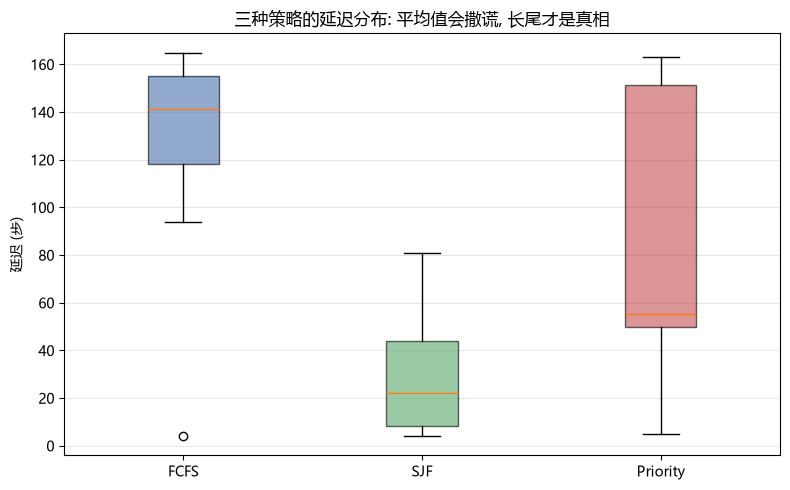

fcfs    : P50= 141.5  P95= 163.5  最大= 165.0  平均= 129.7
sjf     : P50=  22.0  P95=  72.0  最大=  81.0  平均=  29.2
priority: P50=  55.5  P95= 161.5  最大= 163.0  平均=  89.1


In [3]:
# -*- coding: utf-8 -*-
import numpy as np                                 # 数值库
import matplotlib.pyplot as plt                   # 绘图库
%matplotlib inline
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

# 重新跑三种策略 (结果已存于上一 cell 的 results)
fig, ax = plt.subplots(figsize=(8, 5))             # 画布
data = [results[p] for p in ["fcfs", "sjf", "priority"]]   # 三组延迟
bp = ax.boxplot(data, patch_artist=True)          # 箱线图
ax.set_xticklabels(["FCFS", "SJF", "Priority"])   # x 轴标签
for patch, color in zip(bp["boxes"], ["#4C72B0", "#55A868", "#C44E52"]):  # 上色
    patch.set_facecolor(color)                     # 填充色
    patch.set_alpha(0.6)                           # 半透明
ax.set_ylabel("延迟 (步)")                          # y 轴
ax.set_title("三种策略的延迟分布: 平均值会撒谎, 长尾才是真相")  # 标题
ax.grid(axis="y", alpha=0.3)                       # 网格
plt.tight_layout()
plt.show()

# 打印分布特征
for p in ["fcfs", "sjf", "priority"]:              # 每种策略
    lat = np.array(results[p])                     # 延迟数组
    p50, p95, mx = np.percentile(lat, [50, 95, 100])  # 三个分位数
    print(f"{p:8s}: P50={p50:6.1f}  P95={p95:6.1f}  最大={mx:6.1f}  平均={lat.mean():6.1f}")

## 6. 公平性:Priority 的优先级失衡 ⚖️

Priority 策略把算力优先让给高优先级,**低优先级请求被系统性拖延**——它们最终仍能跑完
(不会真的饿死),但平均等待可能比高优先级高一个数量级。我们把 Priority 的结果按优先级分组,
看每组的平均等待,量化这种失衡。

⚠️ **优先级失衡的量化**。如果低优先级组的平均等待远大于高优先级组,说明策略在**系统性**牺牲低优先级请求(它们仍能跑完,只是被严重拖延;「从未开始」列验证了在本模拟里无人真的饿死)。真实系统里这属于不公平 / 饥饿风险,通常用**权重轮询(WRR)**、**配额**或**等待时间提升**缓解。

In [4]:
# -*- coding: utf-8 -*-
import numpy as np                                 # 数值库
import matplotlib.pyplot as plt                   # 绘图库
%matplotlib inline
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

# 重新造带优先级的请求并跑 priority 策略 (统计每个优先级的平均等待)
rng = np.random.default_rng(11)                    # 与第 4 节相同的随机种子
reqs = [SReq(i, 0.0,
             int(rng.integers(2, 16)),
             int(rng.integers(2, 12)),
             int(rng.integers(0, 3)))
        for i in range(20)]
for r in reqs:
    r.total = r.prompt_len + r.max_new

s = Scheduler(policy="priority", token_budget=8)
step = 0
while not all(r.state == "FINISHED" for r in reqs) and step < 6000:
    s.schedule([r for r in reqs if r.state == "WAITING" and r.arrive <= step])
    step += 1

# 按优先级分组统计
print("优先级 | 平均等待 | 平均延迟 | 请求数 | 饿死(从未开始)")
for pri in sorted({r.priority for r in reqs}):     # 每个优先级
    grp = [r for r in reqs if r.priority == pri]   # 该优先级请求
    started = [r for r in grp if r.start is not None]  # 已开始的请求 (未被饿死)
    starved = len(grp) - len(started)              # 从未被调度的请求数 (饿死)
    waits = [r.start - r.arrive for r in started]  # 等待时间 (只看已开始的)
    lats = [r.end - r.arrive for r in started]     # 延迟
    avg_w = float(np.mean(waits)) if waits else float("nan")  # 平均等待 (空则 NaN)
    avg_l = float(np.mean(lats)) if lats else float("nan")    # 平均延迟
    print(f"{pri:6d} | {avg_w:7.1f}步 | {avg_l:7.1f}步 | {len(grp):4d} | {starved}")

优先级 | 平均等待 | 平均延迟 | 请求数 | 饿死(从未开始)
     0 |     7.2步 |    23.8步 |    5 | 0
     1 |    42.5步 |    86.2步 |    6 | 0
     2 |   113.7步 |   267.0步 |    9 | 0


## 7. 调度器为什么必须存在于 token 预算与抢占 🔗

策略讲完,回到一个更根本的问题:**为什么 token 预算必须存在?**
做 预算 × 策略 双扫描:预算太小 → 每步只放一个请求 → 大家抢同一块算力(等待 = 墙钟);
预算太大 → 每步吃满但边际递减。调度策略的差别只在预算中等时最明显——这就是调参时要找的区间。

🔢 **前因后果落到数字**。预算=1 时大家都在排队(等待=墙钟,策略差异被淹没);
预算足够大时大家都能马上进场(策略差异也变小)。**策略的价值在预算中等时最大**。

In [5]:
# -*- coding: utf-8 -*-
import numpy as np                                 # 数值库

def run_policy_at(policy, budget, n=20, seed=11):
    """指定预算跑一遍, 返回平均延迟。"""
    rng = np.random.default_rng(seed)              # 固定种子
    reqs = [SReq(i, 0.0,
                 int(rng.integers(2, 16)),
                 int(rng.integers(2, 12)),
                 int(rng.integers(0, 3)))
            for i in range(n)]
    for r in reqs:
        r.total = r.prompt_len + r.max_new
    s = Scheduler(policy=policy, token_budget=budget)
    step = 0
    while not all(r.state == "FINISHED" for r in reqs) and step < 10000:
        s.schedule([r for r in reqs if r.state == "WAITING" and r.arrive <= step])
        step += 1
    for r in reqs:                                 # 处理饥饿未完成
        if r.end is None:                          # 从未完成
            r.end = float(step)                    # 近似为当前步
    return float(np.mean([r.end - r.arrive for r in reqs]))  # 平均延迟

budgets = [1, 2, 4, 8, 16]                     # 预算扫描区间
print("预算 | FCFS平均延迟 | SJF平均延迟 | Priority平均延迟")
rows = []
for b in budgets:                                  # 每个预算
    row = [run_policy_at("fcfs", b), run_policy_at("sjf", b), run_policy_at("priority", b)]  # 三策略
    rows.append(row)                               # 收集
    print(f"{b:4d} | {row[0]:10.1f} | {row[1]:9.1f} | {row[2]:14.1f}")

预算 | FCFS平均延迟 | SJF平均延迟 | Priority平均延迟


   1 |     1890.7 |    5747.9 |         5057.1


   2 |      808.6 |    2929.2 |         1710.8


   4 |      392.1 |     222.2 |          448.6
   8 |      202.5 |      46.7 |          151.9
  16 |       49.7 |      15.4 |           41.4


## 8. 真实 GPU:给 token 预算一个物理刻度 ⏱️

上面的预算/策略都是「步」的单位。落到真实硬件,**一个 token 预算 = 真实的一次 decode
迭代**。我们用 `vllm_real` 实测不同 batch 下每步的真实耗时,画出「每步 token 数 vs 吞吐」曲线。

📡 **同一段 GPU 时间片,批次越大吞吐越高**——所以调度器的职责之一就是**别让预算空转**:每步尽量把 batch 装满(token 预算顶格用),这正是 continuous batching 的日常。

In [6]:
# -*- coding: utf-8 -*-
import sys, os                                   # 系统库
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")  # OpenMP 兼容
sys.path.insert(0, r"D:\Project\21-Cpp_learn\explore\VLLM_learn\exercises")
from vllm_real import bench_throughput_curve, cuda_info   # 跨章共享真实微基准

print("设备:", cuda_info())                        # 设备信息
b_list, tps, mps = bench_throughput_curve(batch=(1, 2, 4, 8, 16, 32), token_len=16, reps=5)
print("每步token | 每步耗时(ms) | 吞吐(token/s)")
for b, ms, tp in zip(b_list, mps, tps):            # 逐行打印
    print(f"{b:8d} | {ms:11.3f} | {tp:12.0f}")

# 换算: 如果 token 预算 = 8, 对应 batch=8 的每步耗时
b8 = dict(zip(b_list, mps)).get(8, 0)              # batch=8 的每步毫秒
print(f"\n=> 若每步预算 8 个 token (batch=8), 一次调度迭代 ≈ {b8:.3f} ms;"
      f"预算 32 时 ≈ {dict(zip(b_list, mps)).get(32, 0):.3f} ms。")

设备: NVIDIA GeForce RTX 5060 Laptop GPU · vram 8.0GiB


每步token | 每步耗时(ms) | 吞吐(token/s)
       1 |       0.375 |         2668
       2 |       0.298 |         6721
       4 |       0.329 |        12163
       8 |       0.334 |        23982
      16 |       0.290 |        55093
      32 |       0.448 |        71434

=> 若每步预算 8 个 token (batch=8), 一次调度迭代 ≈ 0.334 ms;预算 32 时 ≈ 0.448 ms。


## 9. 与 vLLM 对接:真实调度器的旋钮 🔗

打开 `vllm/config/scheduler.py`,你会看到本课所有概念的「真身」:

| 本课概念 | vLLM 字段 | 默认值 | 说明 |
|---|---|---|---|
| token 预算 | `max_num_batched_tokens` | 2048 | 每步最多处理的 token 数 |
| 每步发放预算 | `max_num_scheduled_tokens` | = 上者 | 调度器每步发放的 token 数 |
| 并发上限 | `max_num_seqs` | 128 | 每步最多同时跑的请求数 |
| 调度策略 | `policy` | `"fcfs"` | 可选 `fcfs` / `priority`(低值优先) |
| 抢占 | 默认 `RECOMPUTE` | — | V1 里重算代替换出 |

vLLM 的 `SchedulerPolicy` 枚举:
```python
class SchedulerPolicy(str, enum.Enum):
    FCFS = "fcfs"          # 按到达顺序
    PRIORITY = "priority"  # 按优先级, 到达时间做 tie-break
```

也就是说,vLLM 默认用 FCFS(简单、公平),`priority` 是可选开关。
而学术界(FastServe 的 MLFQ、Learning-to-Rank 的 SJF 近似)在探索更激进的策略——
它们共同面临**公平性**的代价(可能让低优先级 / 长请求被严重拖延),这正是本课第 6 节量化的问题。

> 📄 引用:FastServe(NSDI'25)指出 FCFS 下排队延迟可占端到端延迟的 **90%**;> Learning-to-Rank(NeurIPS'24)用排序预测近似 SJF,把平均延迟降低最多 6.9×。

## 10. 🖥️ Streamlit 动态演示:三策略同屏 PK

运行 `app_17_scheduler_demo.py`:策略 / 预算 / 分布三旋钮 + 实时调度表。

### 📜 App 完整源码(`app_17_scheduler_demo.py` 嵌入)

▶️ 此 cell 在 streamlit 环境中才真正运行;在 notebook 中仅作展示。

In [7]:
try:
    import streamlit as st
    _IS_STREAMLIT = bool(st.runtime.exists())
except Exception:
    _IS_STREAMLIT = False

if _IS_STREAMLIT:
    # -*- coding: utf-8 -*-
    # app_17_scheduler_demo.py — 调度策略演示 🎛️
    import numpy as np
    import pandas as pd
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    import streamlit as st
    from dataclasses import dataclass

    st.set_page_config(page_title="调度策略演示 🎛️", layout="wide")
    st.title("🎛️ 第 17 课 · Scheduler 设计:token 预算 × 调度策略")

    st.markdown("""
    调度器 = **预算(每步能算多少 token)+ 策略(先服务谁)**。
    本演示可切换 `FCFS / SJF / Priority` 三种策略、调节 token 预算与请求分布,
    实时查看**每一步的调度决策**、延迟分布与 FCFS 基准对比。
    """)

    # ---------------------------------------------------------------- 模拟器(与 notebook 一致)
    @dataclass
    class Req:
        rid: int; arrive: float; prompt_len: int; max_new: int
        priority: float = 0.0
        state: str = "WAITING"; start: float = None; end: float = None
        generated: int = 0; prefilled: int = 0

    def make_reqs(n, dist, seed, plen=(5, 30), mnew=(5, 20)):
        rng = np.random.default_rng(seed)
        reqs, t = [], 0.0
        for i in range(n):
            t += rng.exponential(1.0 / 0.6)
            p = int(rng.integers(plen[0], plen[1] + 1))
            m = int(rng.integers(mnew[0], mnew[1] + 1))
            if dist == "长尾(20% 超长请求)":
                if rng.random() < 0.2:
                    p = int(p * 2.5); m = int(m * 2.5)
            reqs.append(Req(i, t, p, m, priority=float(rng.random())))
        return reqs

    def pick_next(waiting, policy):
        if policy == "FCFS":
            return sorted(waiting, key=lambda r: r.arrive)
        if policy == "SJF":
            return sorted(waiting, key=lambda r: r.prompt_len + r.max_new)
        if policy == "Priority":
            return sorted(waiting, key=lambda r: -r.priority)
        raise ValueError(policy)

    class SimpleScheduler:
        """手写简化调度器:一次 schedule() = 一个迭代的完整调度决策"""
        def __init__(self, token_budget=8, policy="FCFS"):
            self.token_budget, self.policy = token_budget, policy
            self.waiting, self.running, self.finished = [], [], []
            self.t, self.done, self.total = 0.0, 0, 0
            self.log = []

        def admit(self, reqs):
            self.total = len(reqs)
            self.waiting.extend(reqs)

        def schedule(self):
            self.waiting = pick_next(self.waiting, self.policy)
            for r in list(self.waiting):
                if r.arrive <= self.t:
                    self.running.append(r); self.waiting.remove(r)
            budget = self.token_budget
            plan = []
            for r in self.running:
                if r.state == "WAITING" and budget > 0 and r.prefilled < r.prompt_len:
                    use = min(budget, r.prompt_len - r.prefilled)
                    budget -= use; r.prefilled += use
                    plan.append((r.rid, use, "prefill"))
                    if r.prefilled >= r.prompt_len:
                        r.state = "RUNNING"
                        if r.start is None:
                            r.start = self.t
            for r in self.running:
                if r.state == "RUNNING" and budget > 0 and r.generated < r.max_new:
                    r.generated += 1; budget -= 1
                    plan.append((r.rid, 1, "decode"))
            for r in list(self.running):
                if r.generated >= r.max_new:
                    r.state, r.end = "FINISHED", self.t
                    self.running.remove(r); self.finished.append(r); self.done += 1
            self.log.append(dict(step=self.t, plan=plan, running=[x.rid for x in self.running]))
            self.t += 1.0

        def run_all(self):
            while self.done < self.total:
                self.schedule()
            return self.waiting + self.running + self.finished, self.log

    # ---------------------------------------------------------------- 参数
    with st.sidebar:
        st.header("🎛️ 参数")
        policy = st.radio("调度策略", ["FCFS", "SJF", "Priority"])
        token_budget = st.slider("token 预算(每步)", 2, 24, 8, 1)
        n = st.slider("请求数量", 8, 40, 20, 1)
        dist = st.radio("请求长度分布", ["均匀", "长尾(20% 超长请求)"])
        seed = st.slider("随机种子", 0, 99, 11, 1)
        compare = st.checkbox("与 FCFS 基准对比", value=True)
        st.caption("💡 预算 ≈ vLLM max_num_scheduled_tokens;策略决定 waiting 队列的取人顺序")

    # ---------------------------------------------------------------- 运行
    s = SimpleScheduler(token_budget, policy)
    s.admit(make_reqs(n, dist, seed))
    reqs, log = s.run_all()
    df = pd.DataFrame([dict(rid=r.rid, arrive=r.arrive, start=r.start, end=r.end,
                            work=r.prompt_len + r.max_new, prio=round(r.priority, 2)) for r in reqs])
    df["latency"] = df["end"] - df["arrive"]
    df["wait"] = df["start"] - df["arrive"]
    ms = float(df.end.max())

    if compare:
        s0 = SimpleScheduler(token_budget, "FCFS")
        s0.admit(make_reqs(n, dist, seed))
        _, _ = s0.run_all()
        d0 = pd.DataFrame([dict(latency=r.end - r.arrive, wait=r.start - r.arrive) for r in s0.waiting + s0.running])

    c1, c2, c3, c4 = st.columns(4)
    c1.metric(f"平均延迟({policy})", f"{df.latency.mean():.1f} 步",
              delta=f"{d0.latency.mean() - df.latency.mean():+.1f} vs FCFS" if compare else None)
    c2.metric("P95 延迟", f"{np.percentile(df.latency, 95):.1f} 步")
    c3.metric("平均等待", f"{df.wait.mean():.1f} 步")
    c4.metric("吞吐(请求/步)", f"{n / ms:.3f}")

    # ---------------------------------------------------------------- 每步调度表
    st.subheader("📋 每步调度决策(最近 12 步)")
    rows = []
    for entry in log[-12:]:
        plan_txt = ", ".join(f"R{rid}+{tk}{'P' if k == 'prefill' else 'D'}" for rid, tk, k in entry["plan"][:8])
        rows.append(dict(步骤=entry["step"], 调度=plan_txt or "空", running=str(entry["running"])))
    st.dataframe(pd.DataFrame(rows), use_container_width=True)
    st.caption("P = prefill token,D = decode token;预算扣完即停——看 budget 如何卡住每一步。")

    # ---------------------------------------------------------------- 延迟分布
    st.subheader("📊 延迟分布")
    fig = make_subplots(rows=1, cols=2, subplot_titles=("延迟直方图", "延迟箱线图"))
    fig.add_trace(go.Histogram(x=df.latency, nbinsx=14, marker_color="#4C78A8",
                               name=policy, opacity=0.85), row=1, col=1)
    fig.add_trace(go.Box(y=df.latency, name=policy, marker_color="#4C78A8", boxmean=True), row=1, col=2)
    if compare:
        fig.add_trace(go.Histogram(x=d0.latency, nbinsx=14, marker_color="#E45756",
                                   name="FCFS", opacity=0.5), row=1, col=1)
        fig.add_trace(go.Box(y=d0.latency, name="FCFS", marker_color="#E45756", boxmean=True), row=1, col=2)
    fig.update_layout(title=f"{policy} 策略下的延迟分布(与 FCFS 对比)", height=380,
                      margin=dict(l=10, r=10, t=50, b=10), showlegend=True)
    st.plotly_chart(fig, use_container_width=True)

    # ---------------------------------------------------------------- 调度时间线
    fig2 = go.Figure()
    for _, row in df.iterrows():
        fig2.add_trace(go.Bar(x=[row.wait], y=[f"R{row.rid}"], base=[row.arrive],
                              orientation="h", marker_color="#BAB0AC", showlegend=False, width=0.6))
        fig2.add_trace(go.Bar(x=[row.latency - row.wait], y=[f"R{row.rid}"], base=[row.start],
                              orientation="h", marker_color="#54A24B", showlegend=False, width=0.6))
    fig2.update_layout(title=f"{policy} 调度甘特图:灰=等待,绿=执行(等待短 = 调度快)",
                       xaxis_title="时间(步)", yaxis_title="请求", height=60 + 28 * n,
                       margin=dict(l=10, r=10, t=40, b=10), bargap=0.2)
    st.plotly_chart(fig2, use_container_width=True)

else:
    print("💡 当前不是 streamlit 环境, 跳过执行本 App。")
    print("    请直接运行: D:\\uv_envs\\uv_cuda\\Scripts\\python.exe -m streamlit run app_17_scheduler_demo.py")


💡 当前不是 streamlit 环境, 跳过执行本 App。
    请直接运行: D:\uv_envs\uv_cuda\Scripts\python.exe -m streamlit run app_17_scheduler_demo.py


### 🏃 运行方法

```
D:\uv_envs\uv_cuda\Scripts\python.exe -m streamlit run app_17_scheduler_demo.py
```
浏览器打开 http://localhost:8501 ,切换策略并拖动预算,观察平均延迟与分布的变化。

## ✅ 本课小结

- token 预算按算力计:∑每步 token ≤ max_num_batched_tokens,prefill 与 decode 重量差异悬殊
- Scheduler 类:schedule() 五步(收请求→清完成→排序→预算拉人→推进),pick_next 是策略插槽
- FCFS 公平;SJF 平均最优但可能严重拖延长请求;Priority 会造成优先级失衡,低优先级被系统性拖延,需要公平性机制
- 平均延迟会撒谎:必须看 P50/P95/最大,箱线图是标准姿势
- 预算 × 策略 双扫描证明:策略价值在预算中等时最大,太小太大都被淹没
- vLLM 默认 FCFS + priority 可选;token 预算的物理刻度 = 每步一次真实 decode

## ✍️ 动手练习

1. 给 Scheduler 加一个 WRR(权重轮询)策略,把低优先级请求按 2:1 权重轮流插入,验证饥饿缓解
2. 在 run_policy 里统计 SJF 策略下「最长请求的等待时间」,量化它被拖延的程度
3. 把第 7 节双扫描画成热力图(预算 × 策略 × 平均延迟),一眼找到最优区间
4. 把 budget=1 与 budget=32 的请求执行顺序打印出来,理解「等待=墙钟」的直觉

## 🔗 延伸阅读

- [vLLM SchedulerConfig 文档](https://docs.vllm.ai/en/latest/api/vllm/config/scheduler/)
- [vLLM V1 调度器源码](https://github.com/vllm-project/vllm/blob/main/vllm/v1/core/sched/scheduler.py)
- [FastServe (NSDI'25)](https://www.usenix.org/conference/nsdi25/presentation/wu-bingyang)
- [Efficient LLM Scheduling by Learning to Rank](https://arxiv.org/abs/2408.15792)

---
> 🎉 恭喜完成本课!下一课见!